# Isolation Forest Baseline on Synthetic Multivariate Outliers

This notebook mirrors the univariate benchmark in `stats_08_general_test_osbad.ipynb`, but extends it to a **multivariate** setting. Instead of a single `value` column, each sample now has two features (`feature_1` and `feature_2`), and the outliers are injected as extreme two-dimensional points that sit far from the inlier cluster.

The workflow is:

* **Generate synthetic data:** create a 2D Gaussian blob of inliers and inject a handful of known multivariate outliers, keeping the ground-truth labels for evaluation.
* **Detect outliers:** run an **Isolation Forest** baseline (no hyperparameter tuning) through the OSBAD `ModelRunner`, which returns a probabilistic outlier score per sample.
* **Evaluate:** compare the predicted outliers against the injected ground truth with a confusion matrix and the standard OSBAD evaluation metrics.

Since the injected outliers are known in advance, they serve as the ground-truth labels for benchmarking the Isolation Forest.

# Import libraries

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library
from pathlib import Path
import pprint

# Third-party libraries
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Custom osbad library for anomaly detection
import osbad.config as bconf
import osbad.hyperparam as hp
import osbad.modval as modval
import osbad.viz as bviz
from osbad.model import ModelRunner

# Synthetic Multivariate Outliers to Test OSBAD

Beyond the Severson and Tohoku battery datasets used elsewhere in this project, we deliberately extend the benchmark to a **synthetic dataset** that is not tied to any specific battery chemistry or application. The goal is to demonstrate that OSBAD generalizes beyond battery applications. Because it operates on generic feature vectors rather than domain-specific signals, the same workflow can be applied to entirely new chemistries and applications without modification.

A synthetic two-dimensional dataset is generated to benchmark the Isolation Forest against a known ground truth:

* **Inliers:** 200 samples drawn from a 2D normal distribution centred at $\mu = 50$ with standard deviation $\sigma = 5$ in each dimension, forming a compact circular cluster.
* **Outliers:** 7 extreme two-dimensional points manually injected far from the inlier cluster (e.g. `[10, 12]`, `[90, 88]`, `[5, 95]`, `[100, 100]`), covering the corners of the feature space.
* **Combined dataset:** the inliers and outliers are stacked into 207 samples and shuffled together with their labels, then stored in `df_multivariate` with an `index`, `feature_1`, and `feature_2` column.
* A fixed random seed (`seed=42`) ensures the dataset is reproducible across runs.

Since the injected outliers are known in advance, their `index` values (`true_outlier_index`) serve as the ground-truth labels for evaluating the Isolation Forest with a confusion matrix.


In [3]:
# Simulate a multivariate (2D) dataset with several outliers
rng = np.random.default_rng(seed=42)

# Generate normally-distributed inliers as a 2D Gaussian blob
n_inliers = 200
inliers = rng.normal(loc=50, scale=5, size=(n_inliers, 2))

# Inject a few extreme multivariate outliers far from the inlier cluster
outliers = np.array([
    [10, 12],
    [90, 88],
    [5, 95],
    [95, 8],
    [15, 90],
    [88, 15],
    [100, 100],
])

# Combine inliers and outliers, keeping track of the ground-truth labels
data = np.vstack([inliers, outliers])
labels = np.concatenate([
    np.zeros(n_inliers, dtype=int),
    np.ones(outliers.shape[0], dtype=int)])

# Shuffle rows and labels together to mix outliers into the dataset
shuffle_idx = rng.permutation(data.shape[0])
data = data[shuffle_idx]
labels = labels[shuffle_idx]

df_multivariate = pd.DataFrame({
    "index": np.arange(data.shape[0]),
    "feature_1": data[:, 0],
    "feature_2": data[:, 1],
})

# Ground-truth outlier index used later for evaluation
true_outlier_index = df_multivariate.loc[
    labels == 1, "index"].to_numpy()

print(f"Number of samples: {df_multivariate.shape[0]}")
print(f"Number of injected outliers: {true_outlier_index.size}")
print(f"Injected outlier index: {true_outlier_index.tolist()}")
df_multivariate.describe()

Number of samples: 207
Number of injected outliers: 7
Injected outlier index: [103, 124, 144, 154, 176, 182, 197]


,index,feature_1,feature_2
count,207.000000,207.000000,207.000000
mean,103.000000,50.362531,50.123589
std,59.899917,9.152865,8.862541
min,0.000000,5.000000,8.000000
25%,51.500000,46.763652,46.425252
50%,103.000000,50.332729,49.756408
75%,154.500000,53.452168,52.823441
max,206.000000,100.000000,100.000000


In [4]:
df_multivariate.to_csv("multivariate_dataset.csv", index=False)

## Plot the synthetic dataset

The scatterplot shows the compact inlier cluster (tomato) with the injected multivariate outliers (crimson crosses) scattered around the edges of the feature space.

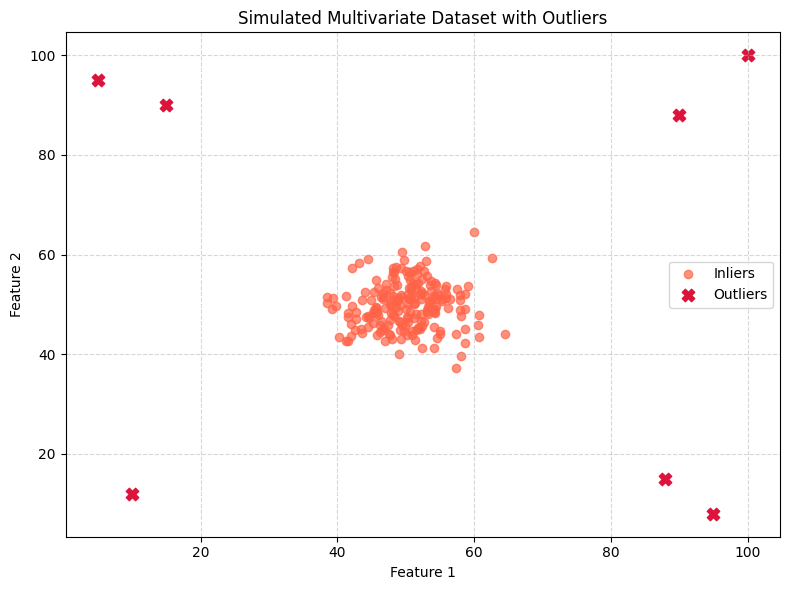

In [5]:
# Plot the multivariate dataset, highlighting the injected outliers
is_outlier = df_multivariate["index"].isin(true_outlier_index)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.rcParams.update(mpl.rcParamsDefault)

ax.scatter(
    df_multivariate.loc[~is_outlier, "feature_1"],
    df_multivariate.loc[~is_outlier, "feature_2"],
    color="tomato",
    label="Inliers",
    alpha=0.7)
ax.scatter(
    df_multivariate.loc[is_outlier, "feature_1"],
    df_multivariate.loc[is_outlier, "feature_2"],
    color="crimson",
    label="Outliers",
    marker="X",
    s=80)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Simulated Multivariate Dataset with Outliers")
ax.legend()
plt.tight_layout()
plt.show()

# Isolation Forest without hyperparameter tuning

The Isolation Forest isolates anomalies by randomly partitioning the feature space: points that are separated in fewer splits receive higher anomaly scores. Here the two synthetic features are used directly as model inputs through the OSBAD `ModelRunner`.

In [6]:
# Label used to organize the figure output for this synthetic dataset
selected_cell_label = "synthetic_multivariate"

# Create a subfolder to store fig output
selected_cell_artifacts_dir = bconf.artifacts_output_dir(
    selected_cell_label)

# Use both synthetic features as model inputs
selected_feature_cols = (
    "feature_1",
    "feature_2")

# Instantiate ModelRunner with selected features and label
runner = ModelRunner(
    cell_label=selected_cell_label,
    df_input_features=df_multivariate,
    selected_feature_cols=selected_feature_cols
)

## Create Xdata for training

In [7]:
# create Xdata array
Xdata = runner.create_model_x_input()

## Fit the model

In [8]:
cfg = hp.MODEL_CONFIG["iforest"]

# create model instance without hyperparameter tuning
model = cfg.baseline_model_param()
model.fit(Xdata)

# Predict probabilistic outlier score
proba = model.predict_proba(Xdata)

# Get predicted outlier index and score from
# the probabilistic outlier score
(pred_outlier_indices,
 pred_outlier_score) = runner.pred_outlier_indices_from_proba(
    proba=proba,
    threshold=0.7,
    outlier_col=cfg.proba_col
)

print("Predicted outlier index:")
print(pred_outlier_indices)
print("-"*70)
print("Predicted corresponding outlier score:")
print(pred_outlier_score)

Predicted outlier index:
[103 124 144 154 176 182 197]
----------------------------------------------------------------------
Predicted corresponding outlier score:
[0.90418902 0.99747684 0.90060828 0.97368364 0.95635487 1.
 0.89703513]


In [9]:
# Access the default hyperparameters without tuning
baseline_model_param = model.get_params()
pprint.pp(baseline_model_param)

{'behaviour': 'new',
 'bootstrap': False,
 'contamination': 0.1,
 'max_features': 1.0,
 'max_samples': 'auto',
 'n_estimators': 100,
 'n_jobs': -1,
 'random_state': 42,
 'verbose': 0}


# Probabilistic outliers prediction

## Predict anomalous samples

In [10]:
df_outliers_pred = df_multivariate[
    df_multivariate["index"]
    .isin(pred_outlier_indices)].copy()

df_outliers_pred["outlier_prob"] = pred_outlier_score
df_outliers_pred

,index,feature_1,feature_2,outlier_prob
103,103,90.0,88.0,0.904189
124,124,10.0,12.0,0.997477
144,144,15.0,90.0,0.900608
154,154,95.0,8.0,0.973684
176,176,5.0,95.0,0.956355
182,182,100.0,100.0,1.000000
197,197,88.0,15.0,0.897035


## Probabilistic anomaly score map

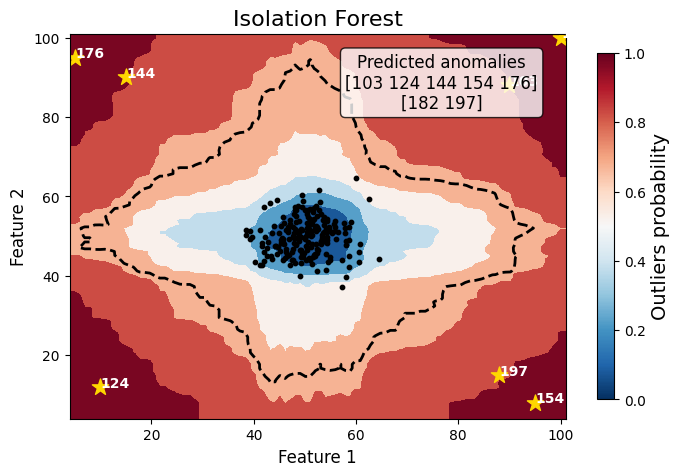

In [11]:
axplot = runner.predict_anomaly_score_map(
    selected_model=model,
    model_name="Isolation Forest",
    xoutliers=df_outliers_pred["feature_1"],
    youtliers=df_outliers_pred["feature_2"],
    pred_outliers_index=pred_outlier_indices,
    threshold=0.7,
    annotation_label="Predicted anomalies"
)

axplot.set_xlabel(
    r"Feature 1",
    fontsize=12)
axplot.set_ylabel(
    r"Feature 2",
    fontsize=12)

output_fig_filename = (
    "anomaly_score_map_iforest_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

## Histogram of the anomaly score

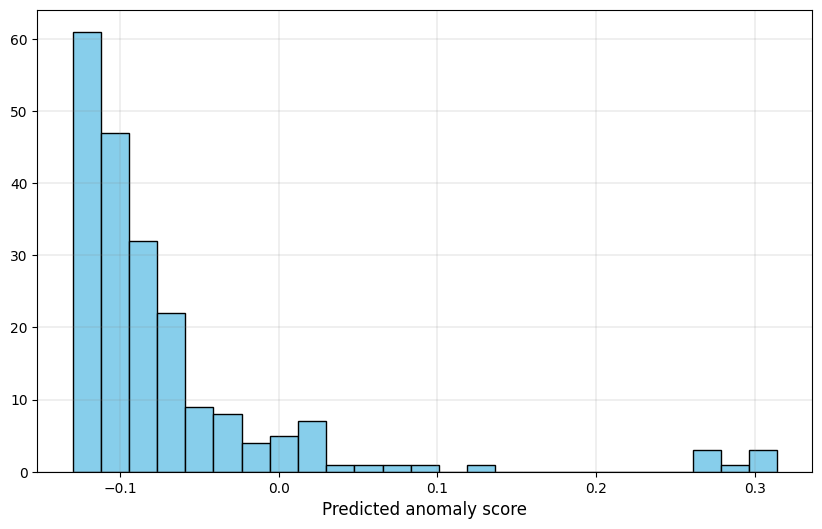

In [12]:
outlier_score = model.decision_function(Xdata)

fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    outlier_score,
    color="skyblue",
    edgecolor="black",
    bins=25)

ax.set_xlabel(
    "Predicted anomaly score",
    fontsize=12)

ax.grid(
    color="grey",
    linestyle="-",
    linewidth=0.25,
    alpha=0.7)

plt.show()

In [13]:
# threshold without hyperparameter tuning
model.threshold_

np.float64(8.890457814381136e-18)

# Model performance evaluation

The predicted outliers are compared against the injected ground-truth outliers. Both label vectors are aligned on the sample `index`, following the same evaluation pattern used in the univariate notebook.

In [14]:
# Compare predicted outliers with the true injected outliers
y_true = df_multivariate["index"].isin(true_outlier_index)
y_pred = df_multivariate["index"].isin(pred_outlier_indices)

## Confusion matrix

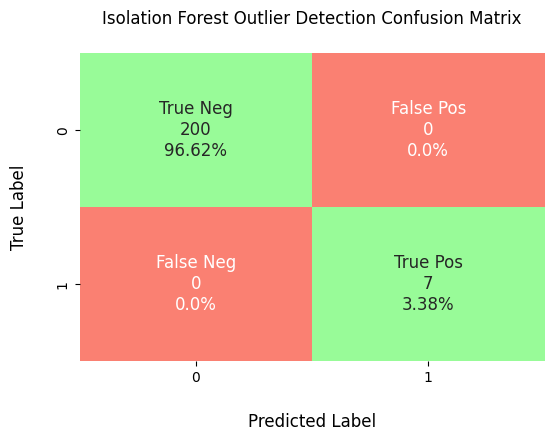

In [15]:
# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

axplot.set_title(
    "Isolation Forest Outlier Detection Confusion Matrix"
    + "\n",
    fontsize=12)

output_fig_filename = (
    "conf_matrix_iforest_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

## Evaluation metrics

The model performance is summarized with five metrics: accuracy, precision, recall, F1-score, and the Matthews Correlation Coefficient (MCC).

$$
\textrm{Accuracy} = \frac{\textrm{TP} + \textrm{TN}}{\textrm{Total prediction}}
$$

$$
\textrm{Precision} = \frac{\textrm{TP}}{\textrm{TP + FP}}
$$

$$
\textrm{Recall} = \frac{\textrm{TP}}{\textrm{TP + FN}}
$$

$$
\textrm{F1-score} = \frac{2(\textrm{Precision}\times \textrm{Recall})}{\textrm{Precision} + \textrm{Recall}}
$$

$$
\textrm{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN+FN)}}
$$

In [16]:
# Assemble the per-sample evaluation dataframe
df_eval_outlier = pd.DataFrame({
    "cycle_index": df_multivariate["index"],
    "true_outlier": np.array(y_true, dtype=int),
    "pred_outlier": np.array(y_pred, dtype=int),
})

df_current_eval_metrics = modval.eval_model_performance(
    model_name="iforest",
    selected_cell_label=selected_cell_label,
    df_eval_outliers=df_eval_outlier)

df_current_eval_metrics

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
MCC-score: 1.0
****************************************************************************************************


,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,iforest,synthetic_multivariate,1.0,1.0,1.0,1.0,1.0


In [17]:
# Export current metrics to CSV
metrics_eval_filepath =  Path.cwd().joinpath(
    "eval_metrics_no_hp_synthetic.csv")

hp.export_current_model_metrics(
    model_name="iforest",
    selected_cell_label=selected_cell_label,
    df_current_eval_metrics=df_current_eval_metrics,
    export_csv_filepath=metrics_eval_filepath,
    if_exists="replace")

Have the metrics for iforest on cell synthetic_multivariate been evaluated before?
True
----------------------------------------------------------------------
Replacing existing row for iforest, synthetic_multivariate.
Metrics for iforest, synthetic_multivariate have been replaced in the CSV file.


,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,knn,synthetic_multivariate,0.990338,1.0,0.714286,0.833333,0.840960
1,gmm,synthetic_multivariate,0.980676,1.0,0.428571,0.600000,0.648204
2,lof,synthetic_multivariate,0.980676,1.0,0.428571,0.600000,0.648204
3,pca,synthetic_multivariate,1.000000,1.0,1.000000,1.000000,1.000000
4,autoencoder,synthetic_multivariate,1.000000,1.0,1.000000,1.000000,1.000000
5,iforest,synthetic_multivariate,1.000000,1.0,1.000000,1.000000,1.000000
